# Обучение нейросетей — оптимизация и регуляризация


В этой домашке надо реализовать Dropout-слой и проследить его влияние на обобщающую способность сети

## Dropout

Как всегда будем экспериментировать на датасете MNIST. MNIST является стандартным бенчмарк-датасетом, и его можно подгрузить средствами pytorch.

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.datasets as dsets
import torchvision.transforms as transforms
import torch.optim as optim
from torch.utils.data.sampler import SubsetRandomSampler

In [ ]:
def seed_everything(seed: int):
    # Импортируем все необходимые модули для управления случайностью в Python, NumPy и PyTorch
    import random, os
    import numpy as np
    import torch

    # Включаем строгий детерминизм в PyTorch: все операции, которые могут быть недетерминированными (например, некоторые CUDA-ядра), будут либо заменены на детерминированные аналоги, либо выдавать ошибку — это гарантирует полную воспроизводимость результатов при условии фиксированного seed
    torch.use_deterministic_algorithms(True)

    # Фиксируем seed для встроенного генератора случайных чисел Python — влияет на random.choice, random.shuffle и т.д.
    random.seed(seed)

    # Устанавливаем переменную окружения PYTHONHASHSEED, чтобы хеширование строк и других объектов было детерминированным между запусками — это критично, так как словари и множества в Python используют хеш-таблицы, и их порядок может влиять на порядок обработки данных
    os.environ['PYTHONHASHSEED'] = str(seed)

    # Фиксируем seed для генератора случайных чисел NumPy — влияет на np.random.randn, np.random.shuffle и любые операции с данными через NumPy
    np.random.seed(seed)

    # Фиксируем seed для CPU-генератора PyTorch — влияет на инициализацию весов, dropout, шум и другие операции на CPU
    torch.manual_seed(seed)

    # Фиксируем seed для GPU-генератора PyTorch (если используется CUDA) — обеспечивает воспроизводимость на GPU
    torch.cuda.manual_seed(seed)

    # Отключаем недетерминированные алгоритмы в cuDNN (CUDA Deep Neural Network library) — заставляет использовать только те алгоритмы, которые дают одинаковый результат при каждом запуске
    torch.backends.cudnn.deterministic = True

    # Включаем benchmark в cuDNN: при первом запуске он протестирует несколько алгоритмов и выберет самый быстрый для текущей конфигурации; однако, если входные размеры меняются от запуска к запуску, это может нарушить воспроизводимость — но при фиксированной архитектуре и данных (как в домашке) это безопасно и ускоряет обучение
    torch.backends.cudnn.benchmark = True

In [ ]:
# Проверяем, выполняется ли код в среде Google Colab:
# get_ipython() возвращает объект интерпретатора Jupyter, а str(get_ipython()) даёт строковое представление (например, '<google.colab._shell.Shell object>');
# если в этой строке содержится подстрока 'google.colab', значит, мы в Colab;
# переменная need_run_tests_and_training будет равна True, если код запущен в Colab, и False — в локальном Jupyter или другом окружении;
# это нужно, чтобы автоматически запускать тесты и обучение только в Colab (где нет интерактивного ввода), а в локальной среде — давать пользователю самому решать, что запускать.
need_run_tests_and_training = 'google.colab' in str(get_ipython())
need_run_tests_and_training

True

In [ ]:
# Задаём базовые гиперпараметры и размеры данных для задачи классификации на MNIST:
input_size = 784      # размер входного вектора: изображение 28x28 пикселей "вытягивается" в вектор длиной 784
num_classes = 10      # количество классов в MNIST (цифры от 0 до 9)
batch_size = 128      # размер батча — сколько изображений обрабатывается за один шаг обучения

# Загружаем обучающий датасет MNIST:
# - root='./MNIST/' — папка, куда будут скачаны данные,
# - train=True — загружаем именно обучающую часть (60 000 изображений),
# - transform=transforms.ToTensor() — автоматически преобразует PIL-изображение в тензор PyTorch и нормализует пиксели в диапазон [0.0, 1.0],
# - download=True — если данных нет в указанной папке, они будут скачаны автоматически.
train_dataset = dsets.MNIST(root='./MNIST/',
                                   train=True,
                                   transform=transforms.ToTensor(),
                                   download=True)

# Загружаем тестовый датасет MNIST:
# - train=False — загружаем тестовую часть (10 000 изображений),
# - transform такой же, чтобы данные были в том же формате, что и обучающие.
test_dataset = dsets.MNIST(root='./MNIST/',
                                  train=False,
                                  transform=transforms.ToTensor())

# Создаём загрузчик обучающих данных (DataLoader):
# - dataset=train_dataset — источник данных,
# - batch_size=batch_size — группируем по 128 изображений,
# - shuffle=True — перемешиваем примеры перед каждой эпохой, чтобы улучшить сходимость SGD (иначе модель может "запомнить" порядок).
train_loader = torch.utils.data.DataLoader(dataset=train_dataset,
                                           batch_size=batch_size,
                                           shuffle=True)

# Создаём загрузчик тестовых данных:
# - shuffle=False — на тесте порядок не важен, и мы не хотим случайности при оценке качества,
# - остальные параметры аналогичны обучающему загрузчику.
test_loader = torch.utils.data.DataLoader(dataset=test_dataset,
                                          batch_size=batch_size,
                                          shuffle=False)

Определим ряд стандартных функций с прошлых семинаров

In [ ]:
# Функция для обучения модели в течение одной эпохи (один проход по всему обучающему датасету)
def train_epoch(model, optimizer, batchsize=32):
    # Инициализируем списки для хранения истории потерь и точности по каждому батчу
    loss_log, acc_log = [], []
    # Переводим модель в режим обучения (включает Dropout, BatchNorm и т.д.)
    model.train()
    # Проходим по всем батчам обучающего загрузчика (train_loader), получая номер батча и данные
    for batch_num, (x_batch, y_batch) in enumerate(train_loader):
        # Распаковываем данные: x_batch — изображения [batch_size, 1, 28, 28], y_batch — метки [batch_size]
        data = x_batch
        target = y_batch

        # Обнуляем градиенты всех параметров модели — обязательно перед каждым шагом, чтобы не накапливались от предыдущих батчей
        optimizer.zero_grad()
        # Прямой проход: получаем логиты (выход модели) для текущего батча
        output = model(data)
        # Находим предсказанный класс как индекс максимального логита (torch.max возвращает (значения, индексы), нам нужны индексы → [1])
        pred = torch.max(output, 1)[1]
        # Вычисляем точность (accuracy) для текущего батча: сравниваем предсказания с истинными метками, преобразуем в float и усредняем
        acc = torch.eq(pred, y_batch).float().mean()
        # Сохраняем точность в историю
        acc_log.append(acc)

        # Вычисляем функцию потерь: используем Negative Log-Likelihood Loss (NLLLoss), которая ожидает на вход логарифм вероятностей (log-softmax);
        # .cpu() перемещает тензор на CPU (на случай, если обучение идёт на GPU) — нужно для совместимости при логировании
        loss = F.nll_loss(output, target).cpu()
        # Обратный проход: вычисляем градиенты потери по всем параметрам модели
        loss.backward()
        # Шаг оптимизатора: обновляем веса модели на основе вычисленных градиентов
        optimizer.step()
        # Преобразуем значение потери из тензора в скаляр Python (для удобства хранения и отображения)
        loss = loss.item()
        # Сохраняем потерю в историю
        loss_log.append(loss)
    # Возвращаем полные списки потерь и точности за эпоху
    return loss_log, acc_log

# Функция для оценки модели на тестовом датасете (без обновления весов)
def test(model):
    # Инициализируем списки для хранения истории потерь и точности по тестовым батчам
    loss_log, acc_log = [], []
    # Переводим модель в режим оценки (отключает Dropout, фиксирует BatchNorm — важно для корректной оценки)
    model.eval()
    # Отключаем вычисление градиентов (экономит память и ускоряет выполнение, так как они не нужны при оценке)
    with torch.no_grad():
        # Проходим по всем батчам тестового загрузчика
        for batch_num, (x_batch, y_batch) in enumerate(test_loader):
            # Распаковываем данные
            data = x_batch
            target = y_batch

            # Прямой проход: получаем предсказания
            output = model(data)
            # Вычисляем потерю (также NLLLoss)
            loss = F.nll_loss(output, target).cpu()

            # Находим предсказанный класс и вычисляем точность
            pred = torch.max(output, 1)[1]
            acc = torch.eq(pred, y_batch).float().mean()
            acc_log.append(acc)

            # Сохраняем скалярное значение потери
            loss = loss.item()
            loss_log.append(loss)
    # Возвращаем списки потерь и точности по тесту
    return loss_log, acc_log

# Функция для визуализации истории обучения: строит график потерь или точности
def plot_history(train_history, val_history, title='loss'):
    # Создаём новую фигуру matplotlib
    plt.figure()
    # Устанавливаем заголовок графика (например, "loss" или "accuracy")
    plt.title('{}'.format(title))
    # Строим кривую обучающей истории (сплошная линия)
    plt.plot(train_history, label='train', zorder=1)

    # Преобразуем историю валидации в массив NumPy (она хранится как список кортежей (шаг, значение))
    points = np.array(val_history)

    # Строим точки валидации (маркеры '+') — каждая точка соответствует концу эпохи
    plt.scatter(points[:, 0], points[:, 1], marker='+', s=180, c='orange', label='val', zorder=2)
    # Подписываем ось X
    plt.xlabel('train steps')

    # Добавляем легенду и сетку для удобства чтения
    plt.legend(loc='best')
    plt.grid()

    # Отображаем график
    plt.show()

# Основная функция обучения модели в течение нескольких эпох
def train(model, opt, n_epochs):
    # Проверяем, нужно ли запускать обучение (например, в Colab — да, локально — возможно, нет)
    if not need_run_tests_and_training:
        return

    # Инициализируем глобальные списки для хранения всей истории обучения
    train_log, train_acc_log = [], []
    val_log, val_acc_log = [], []

    # Цикл по эпохам
    for epoch in range(n_epochs):
        print("Epoch {0} of {1}".format(epoch, n_epochs))
        # Обучаем модель на одной эпохе и получаем историю по батчам
        train_loss, train_acc = train_epoch(model, opt, batchsize=batch_size)

        # Оцениваем модель на тестовом наборе
        val_loss, val_acc = test(model)

        # Добавляем все значения потерь и точности за эпоху в общую историю
        train_log.extend(train_loss)
        train_acc_log.extend(train_acc)

        # Вычисляем номер шага, на котором заканчивается текущая эпоха:
        # общее число обучающих примеров / размер батча = количество батчей в эпохе
        steps = train_dataset.train_labels.shape[0] / batch_size
        # Сохраняем среднюю потерю и точность на тесте как точку (номер_шага, значение) — для графика валидации
        val_log.append((steps * (epoch + 1), np.mean(val_loss)))
        val_acc_log.append((steps * (epoch + 1), np.mean(val_acc)))

        # Очищаем вывод Jupyter-ноутбука, чтобы графики не накапливались
        clear_output()
        # Строим графики потерь и точности
        plot_history(train_log, val_log)
        plot_history(train_acc_log, val_acc_log, title='accuracy')

        # Выводим текущие результаты валидации
        print("Epoch: {2}, val loss: {0}, val accuracy: {1}".format(np.mean(val_loss), np.mean(val_acc), epoch))

Создайте простейшую однослойную модель - однослойную полносвязную сеть и обучите ее с параметрами оптимизации, заданными ниже.

In [ ]:
# Создаём простейшую однослойную полносвязную нейросеть с помощью nn.Sequential:
# Sequential — это контейнер в PyTorch, который позволяет последовательно "складывать" слои друг за другом;
# данные проходят через каждый слой в том порядке, в котором они указаны;
# это удобная альтернатива написанию класса с forward(), когда архитектура линейная (без ветвлений или сложных соединений).
model = nn.Sequential(
    # nn.Flatten(1): "вытягивает" входной тензор, начиная с измерения 1 (то есть сохраняет размер батча, но объединяет все остальные измерения в один вектор);
    # например, изображение [batch_size, 1, 28, 28] → [batch_size, 784];
    # без этого Linear не сможет принять 4D-тензор.
    nn.Flatten(1),
    # nn.Linear(input_size, num_classes): полносвязный слой, который преобразует вектор 784 → 10 (логиты для каждого класса);
    # это и есть "один слой" нашей модели — именно здесь происходят обучаемые преобразования.
    nn.Linear(input_size, num_classes), #10 комбинаций с 784 признаками
    # nn.LogSoftmax(dim=-1): применяет softmax к логитам(К 10 лк с 784 признаками), а затем берёт логарифм;
    # dim=-1 означает "последнее измерение" — то есть по классам;
    # это нужно, потому что функция потерь F.nll_loss (Negative Log-Likelihood Loss) ожидает на вход логарифмы вероятностей, а не сырые логиты.
    nn.LogSoftmax(dim=-1)
)


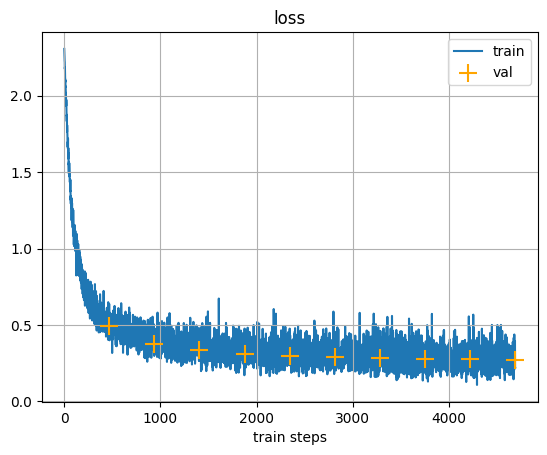

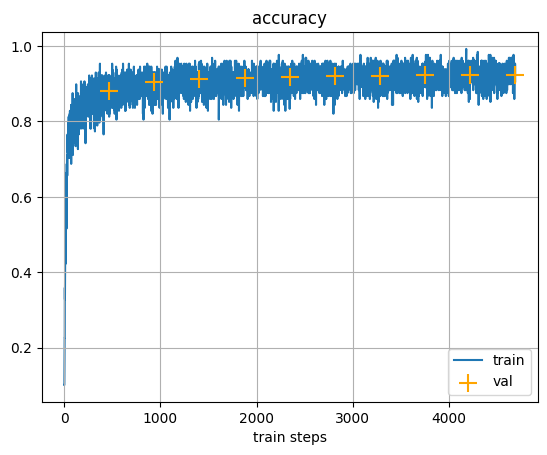

Epoch: 9, val loss: 0.2739995563096261, val accuracy: 0.9232594966888428


In [ ]:
# Создаём оптимизатор Adam с заданными параметрами:
# - model.parameters() — передаём все обучаемые параметры модели (веса и смещения из Linear);
# - lr=0.0005 — скорость обучения (learning rate), подобранная для стабильного обучения на MNIST.
opt = torch.optim.Adam(model.parameters(), lr=0.0005)

# Запускаем обучение модели на 10 эпох с помощью ранее определённой функции train():
# функция train() будет вызывать train_epoch() и test(), обновлять веса, строить графики и выводить результаты.
train(model, opt, 10)

Параметром обученной нейросети является матрица весов, в которой каждому классу соответствует один из 784-мерных столбцов. Визуализируйте обученные векторы для каждого из классов, сделав их двумерными изображениями 28-28. Для визуализации можно воспользоваться кодом для визуализации MNIST-картинок с предыдущих семинаров.

In [ ]:
# Получаем форму матрицы весов второго слоя (Linear(784, 10)) — ожидаем [10, 784]:
# - 10 строк: по одной для каждого класса (цифры 0–9),
# - 784 столбца: по одному для каждого входного пикселя (28×28 = 784).
# Важно: в PyTorch nn.Linear хранит веса как [out_features, in_features], то есть [10, 784].
model._modules['1'].weight.shape

torch.Size([10, 784])

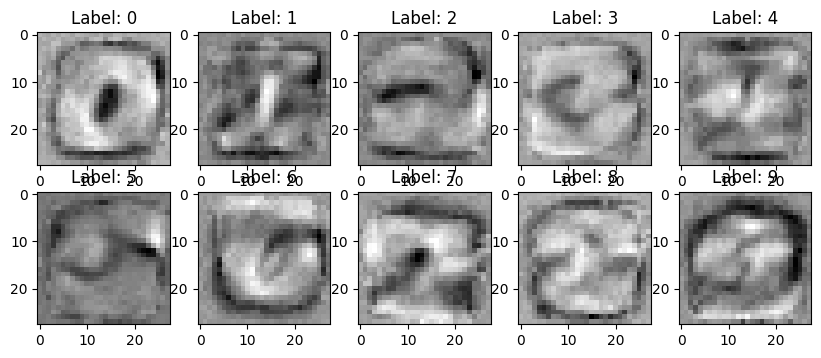

In [ ]:
# Извлекаем обученные веса из модели и преобразуем в массив NumPy:
# - .detach() отключает тензор от графа вычислений (чтобы не сохранялись градиенты),
# - .numpy() конвертирует тензор PyTorch в массив NumPy для удобства визуализации.
weights = model._modules['1'].weight.detach().numpy()

# Создаём фигуру matplotlib размером 10×10 дюймов для размещения всех 10 изображений
plt.figure(figsize=[10, 10])

# Проходим по каждому из 10 классов (цифр 0–9)
for i in range(10):
    # Размещаем изображение в сетке 5×5 (хотя используем только первые 10 ячеек)
    plt.subplot(5, 5, i + 1)
    # Устанавливаем заголовок с меткой класса
    plt.title("Label: %i" % i)
    # Визуализируем i-ю строку матрицы весов как изображение:
    # - weights[i] — это 784-мерный вектор весов, соответствующий i-му классу,
    # - .reshape([28, 28]) преобразует его обратно в матрицу 28×28 (как исходное изображение),
    # - cmap='gray' отображает значения как оттенки серого (положительные веса — белые, отрицательные — чёрные).
    plt.imshow(weights[i].reshape([28, 28]), cmap='gray');

Реализуйте Dropout-слой для полносвязной сети. Помните, что этот слой ведет себя по-разному во время обучения и во время применения.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class DropoutLayer(nn.Module):  # не надо переименовывать этот класс
    """
    Реализация слоя Dropout, аналогичного torch.nn.Dropout.
    Во время обучения:
      - С вероятностью p зануляет каждый элемент входного тензора,
      - Оставшиеся элементы масштабируются на 1/(1-p), чтобы сохранить математическое ожидание.
    Во время оценки (model.eval()):
      - Слой ничего не делает (пропускает данные "как есть").
    """
    def __init__(self, p=0.5, inplace=False):
        super().__init__()
        # Вероятность отключения (dropout rate): доля нейронов, которые будут занулены
        self.p = p
        # Флаг: выполнять ли операцию "на месте" (in-place), чтобы сэкономить память
        self.inplace = inplace

    def forward(self, input):
        # Проверяем, в каком режиме находится модель: обучение (train) или оценка (eval)
        if self.training:
            # === Режим обучения ===
            # 1. Генерируем случайную маску того же размера, что и input,
            #    где каждый элемент ~ Bernoulli(1 - p) (т.е. вероятность "остаться" = 1 - p)
            #    torch.rand_like создаёт тензор с равномерными числами в [0, 1)
            #    Сравнение < (1 - p) даёт True с вероятностью (1 - p)
            mask = torch.rand_like(input) < (1.0 - self.p)

            # 2. Преобразуем маску в float (True → 1.0, False → 0.0)
            #    Это нужно, чтобы умножать на неё
            mask = mask.float()

            # 3. Масштабируем маску: делим на (1 - p), чтобы компенсировать зануление
            #    Это обеспечивает, что E[output] = E[input] (сохраняется среднее значение)
            mask = mask / (1.0 - self.p)

            # 4. Применяем маску к входу: output = input * mask
            if self.inplace:
                # Если inplace=True — модифицируем исходный тензор (экономия памяти)
                input *= mask
                return input
            else:
                # Иначе — создаём новый тензор
                return input * mask

        else:
            # === Режим оценки (model.eval()) ===
            # Dropout отключается: слой просто пропускает данные без изменений
            # Это критически важно для корректной оценки модели!
            return input

In [ ]:
from tqdm.auto import tqdm

def test_dropout_train():

    zero_proba = 0.9
    do = DropoutLayer(p=zero_proba, inplace=False)

    assert do.p == zero_proba, f"{do.p} != {zero_proba}"

    do.train()

    input_tensor = torch.rand( (7, 3, 28, 28) )
    input_tensor_clone = input_tensor.clone()

    dropouted_tensor = do(input_tensor)

    assert (input_tensor_clone == input_tensor).all(), "Input tensor was changed. Avoid implicit inplace tensor modification inside your Modules"

    zeroed_values = (dropouted_tensor == 0).sum()
    # print("input_tensor.numel()", input_tensor.numel())
    expected_zeroed_values = input_tensor.numel() * do.p

    assert (zeroed_values - expected_zeroed_values).abs() < 200, f"zeroed_values={zeroed_values} expected_zeroed_values={expected_zeroed_values}"

    input_module = input_tensor.abs().sum()
    output_module = dropouted_tensor.abs().sum()
    module_diff = (input_module - output_module).abs()
    assert module_diff < 1000, f"input_norm {input_module}, outout_norm {output_module}, diff={module_diff}"

def test_dropout_eval():

    with torch.no_grad():

        zero_proba = 0.9
        do = DropoutLayer(p=zero_proba, inplace=False)

        assert do.p == zero_proba, f"{do.p} != {zero_proba}"

        do.eval()

        input_tensor = torch.rand( (7, 3, 28, 28) )
        input_tensor_clone = input_tensor.clone()

        dropouted_tensor = do(input_tensor)

        assert (input_tensor_clone == input_tensor).all(), "Input tensor was changed. Avoid implicit inplace tensor modification inside your Modules"
        assert (dropouted_tensor == input_tensor_clone).all(), "Output tensor differs from the input one"

seed_everything(42)

if need_run_tests_and_training:
    for _ in tqdm(range(100)):
        test_dropout_train()
        test_dropout_eval()

  0%|          | 0/100 [00:00<?, ?it/s]

Добавьте Dropout-слой в архитектуру сети, проведите оптимизацию с параметрами, заданными ранее, визуализируйте обученные веса. Есть ли разница между весами обученными с Dropout и без него? Параметр Dropout возьмите равным 0.7

In [ ]:
# Создаём новую модель с Dropout-слоем, вставленным СРАЗУ ПОСЛЕ Flatten:
# Важно: Dropout применяется к входным признакам (пикселям), а не к выходу Linear.
# Это означает, что на каждом шаге обучения случайные 70% пикселей изображения будут занулены,
# что заставляет модель не полагаться на отдельные пиксели, а учиться использовать глобальные паттерны.
modelDp = nn.Sequential(
    nn.Flatten(1),              # Преобразует [B, 1, 28, 28] → [B, 784]
    DropoutLayer(p=0.7),        # Применяет Dropout к вектору пикселей с вероятностью отключения 0.7 (очень агрессивный!)
    nn.Linear(28 * 28, 10),     # Полносвязный слой: 784 → 10
    nn.LogSoftmax(dim=-1)       # Логарифм вероятностей для NLLLoss
)


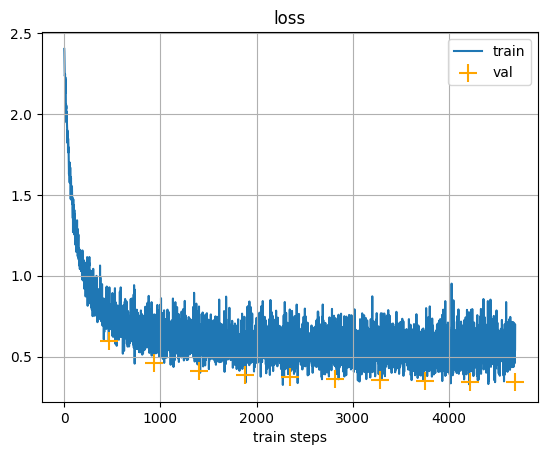

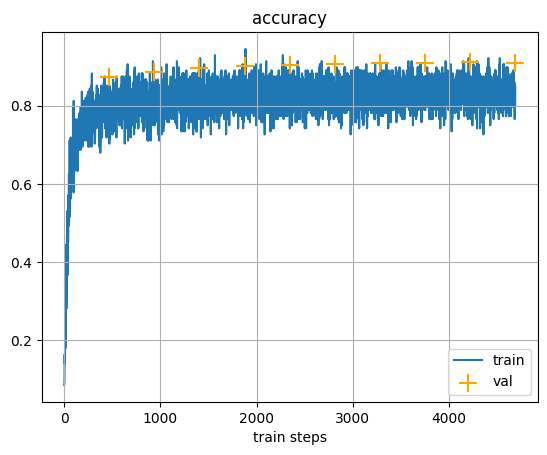

Epoch: 9, val loss: 0.3440270136240162, val accuracy: 0.909414529800415


In [ ]:
# Создаём оптимизатор Adam с теми же параметрами, что и раньше (для честного сравнения)
opt = torch.optim.Adam(modelDp.parameters(), lr=0.0005)

# Запускаем обучение модели на 10 эпох
# Функция train() автоматически вызывает model.train() и model.eval() в нужных местах,
# поэтому Dropout будет корректно работать: включён при обучении, выключен при оценке.
train(modelDp, opt, 10)

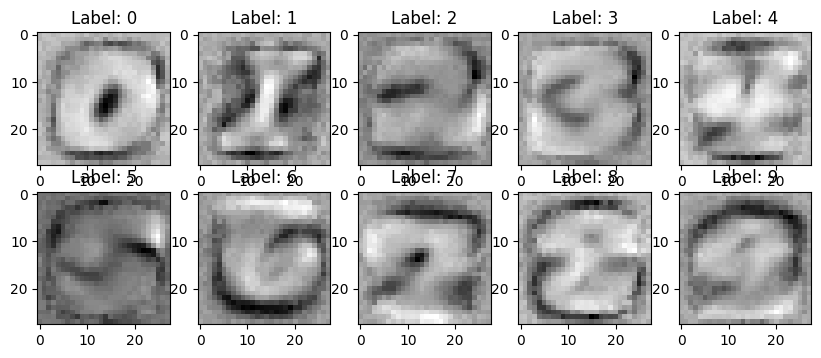

In [ ]:
weights = modelDp._modules['2'].weight.detach().numpy()
plt.figure(figsize=[10, 10])
for i in range(10):
    plt.subplot(5, 5, i + 1)
    plt.title("Label: %i" % i)
    plt.imshow(weights[i].reshape([28, 28]), cmap='gray');

Обучите еще одну модель, в которой вместо Dropout-регуляризации используется L2-регуляризация с коэффициентом 0.05. (Параметр weight_decay в оптимизаторе). Визуализируйте веса и сравните с двумя предыдущими подходами.

In [ ]:
# Создаём третью модель — без Dropout, но с L2-регуляризацией через weight_decay:
# Эта модель архитектурно идентична первой (без Dropout), но оптимизатор будет применять штраф за большие веса.
model = nn.Sequential(
    nn.Flatten(1),                      # Преобразует изображение в вектор 784
    nn.Linear(input_size, num_classes),  # Линейный слой: 784 → 10
    nn.LogSoftmax(dim=-1)               # Логарифм вероятностей для NLLLoss
)


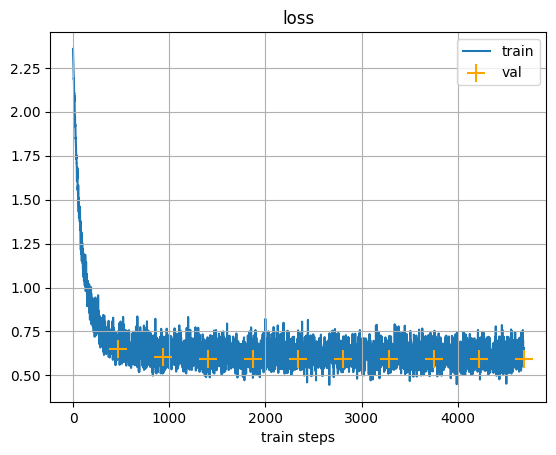

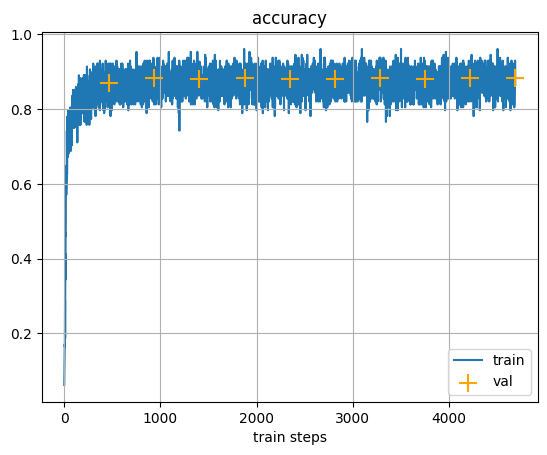

Epoch: 9, val loss: 0.5936284619796125, val accuracy: 0.8842958807945251


In [ ]:
# Создаём оптимизатор Adam с параметром weight_decay=0.05:
# - weight_decay добавляет L2-штраф к функции потерь: loss_total = loss + 0.05 * sum(weights^2)
# - Это эквивалентно тому, что на каждом шаге веса "стягиваются" к нулю,
#   что предотвращает переобучение и делает модель более гладкой.
opt = torch.optim.Adam(model.parameters(), lr=0.0005, weight_decay=0.05)

# Запускаем обучение на 10 эпох
# Важно: в отличие от Dropout, L2-регуляризация работает как во время обучения, так и во время оценки,
# потому что она влияет на сами значения весов, а не на промежуточные активации.
train(model, opt, 10)

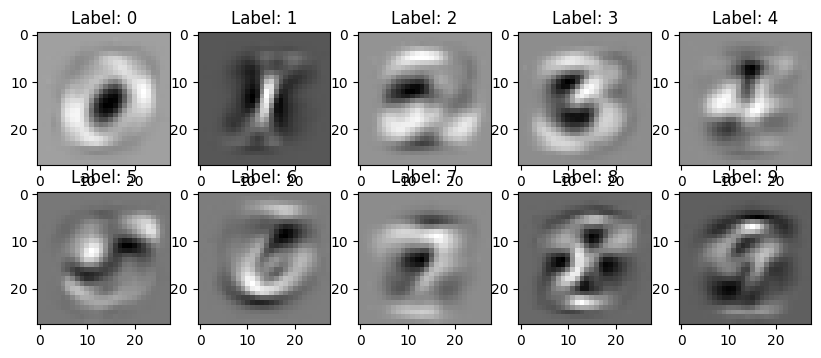

In [ ]:
weights = model._modules['1'].weight.detach().numpy()
plt.figure(figsize=[10, 10])
for i in range(10):
    plt.subplot(5, 5, i + 1)
    plt.title("Label: %i" % i)
    plt.imshow(weights[i].reshape([28, 28]), cmap='gray');